In [1]:
import numpy as np
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import torch
import torch.nn.functional as F
from groupy import *

# R^2/Z_2 Visualization

## Load data and compute embedded data

In [18]:
N = 1000

# Set device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Load trained parameters
templates_np = np.load('templates_trained.npy')
L_np = np.load('L_trained.npy')

templates = torch.from_numpy(templates_np).float().to(device)
L = torch.from_numpy(L_np).float().to(device)

# Normalize templates
norm_templates = F.normalize(templates, dim=1)

# Load your input X (shape: d x n)
X_np = np.random.normal(1, 1, size=(2, N))
X = torch.from_numpy(X_np).float().to(device)

# Define your group (use the same pmId you used in training)
G = GPU_GroupAction(pmId, X.shape[0], device=device)
X_orbits = G.get_orbits(X)

# Apply max filter and linear layer
with torch.no_grad():
    filtered_features = max_filter(norm_templates, X_orbits)
    output = L @ filtered_features  # shape: target_dim x n

# If you want it as numpy array
Y = output.cpu().numpy()

RuntimeError: einsum(): subscript d has size 2 for operand 1 which does not broadcast with previously seen size 50

# Visualize in 3D using PCA

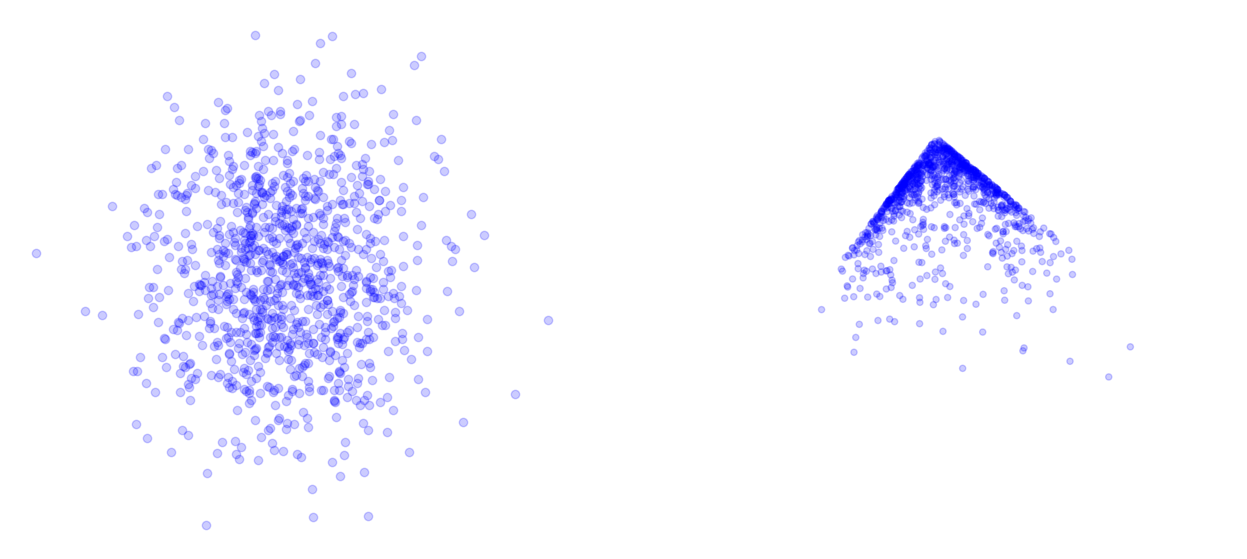

In [56]:
# X_np: original input, shape (2, n_samples)
# Y: model output, shape (target_dim, n_samples)
Y_T = Y.T  # shape: (n_samples, target_dim)

# PCA for Y to 3D
n_comp_Y = min(3, Y_T.shape[0], Y_T.shape[1])
pca_Y = PCA(n_components=n_comp_Y)
Y_pca = pca_Y.fit_transform(Y_T)
if Y_pca.shape[1] < 3:
    padded = np.zeros((Y_pca.shape[0], 3))
    padded[:, :Y_pca.shape[1]] = Y_pca
    Y_pca = padded

# Side-by-side scatterplots
fig = plt.figure(figsize=(16, 7))

# Left: X_np scatter (2D)
ax1 = fig.add_subplot(121)
ax1.scatter(X_np[0, :], X_np[1, :], c='blue', alpha=0.2)
ax1.set_axis_off()

# Right: Y PCA scatter (3D)
ax2 = fig.add_subplot(122, projection='3d')
ax2.scatter(Y_pca[:, 0], Y_pca[:, 1], Y_pca[:, 2], c='blue', alpha=0.2)
ax2.view_init(elev=10, azim=-180)
ax2.set_axis_off()

plt.savefig("Z2_embedding_visual")

# Visualizing Districts 

## Load district outlines and compute embedded data

In [2]:
districts = np.load('district_outlines.npy')

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Load trained parameters
templates_np = np.load('templates_trained.npy')
L_np = np.load('L_trained.npy')

templates = torch.from_numpy(templates_np).to(torch.complex64).to(device)
L = torch.from_numpy(L_np).float().to(device)

# Normalize templates
norm_templates = F.normalize(templates, dim=1)

X = torch.from_numpy(districts).to(torch.complex64).to(device)

# Apply max filter and linear layer
with torch.no_grad():
    filtered_features = shape_max_filter(norm_templates, X)
    output = L @ filtered_features  # shape: target_dim x n

# If you want it as numpy array
Y = output.cpu().numpy()

# Visualize Districts with PCA

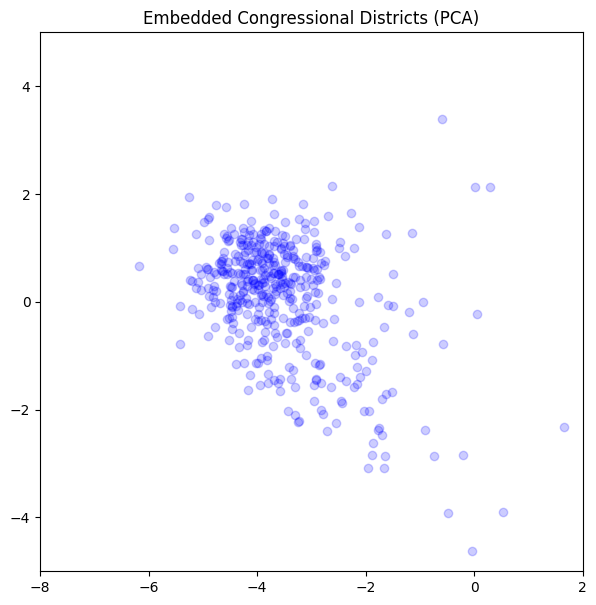

In [29]:
# Y_T: (n_samples, target_dim)
Y_T = Y.T  

# PCA for Y to 2D
pca_Y = PCA(n_components=20)
Y_pca = pca_Y.fit_transform(Y_T)

# Side-by-side scatterplots
fig = plt.figure(figsize=(7,7))

plt.scatter(Y_pca[:, 0], Y_pca[:, 1], c='blue', alpha=0.2)
plt.title("Embedded Congressional Districts (PCA)", fontsize=12)
plt.xlim(-8,2)
plt.ylim(-5,5)

plt.savefig("district_embedding_visual")
plt.show()

In [18]:
pca_Y.singular_values_

array([808.83527  , 194.19038  , 123.32614  ,  79.22254  ,  43.61038  ,
        23.61923  ,  17.904978 ,  16.888533 ,  12.874499 ,  11.353391 ,
         8.578672 ,   6.3778625,   5.923793 ,   5.389953 ,   4.9205036,
         4.735429 ,   4.036401 ,   3.6413305,   3.540778 ,   3.4060674],
      dtype=float32)